# 实验二：语言学定律与词典分词算法

## 第一部分：验证齐夫定律

In [2]:
import os, collections
import matplotlib.pyplot as plt
import numpy as np

# Matplotlib全局配置
plt.rc('font', family='SimHei', weight='bold', size=16)
plt.rc('axes', unicode_minus=False)
%config InlineBackend.figure_format = "retina"

# 加载语料并统计词频
sighan05 = "./corpus_data/第二届国际中文分词评测/icwb2-data/"
msr_corpus_path = os.path.join(sighan05, 'training', 'as_training.utf8')
word_counts = collections.Counter(open(msr_corpus_path, encoding="utf-8").read().split())

print(f"语料库中不同词的总数: {len(word_counts)}")
print("频率最高的10个词:", word_counts.most_common(10))

语料库中不同词的总数: 141338
频率最高的10个词: [('，', 457059), ('的', 277528), ('。', 179490), ('是', 80014), ('一', 59498), ('在', 57221), ('、', 48420), ('了', 46437), ('有', 44433), ('我', 39946)]


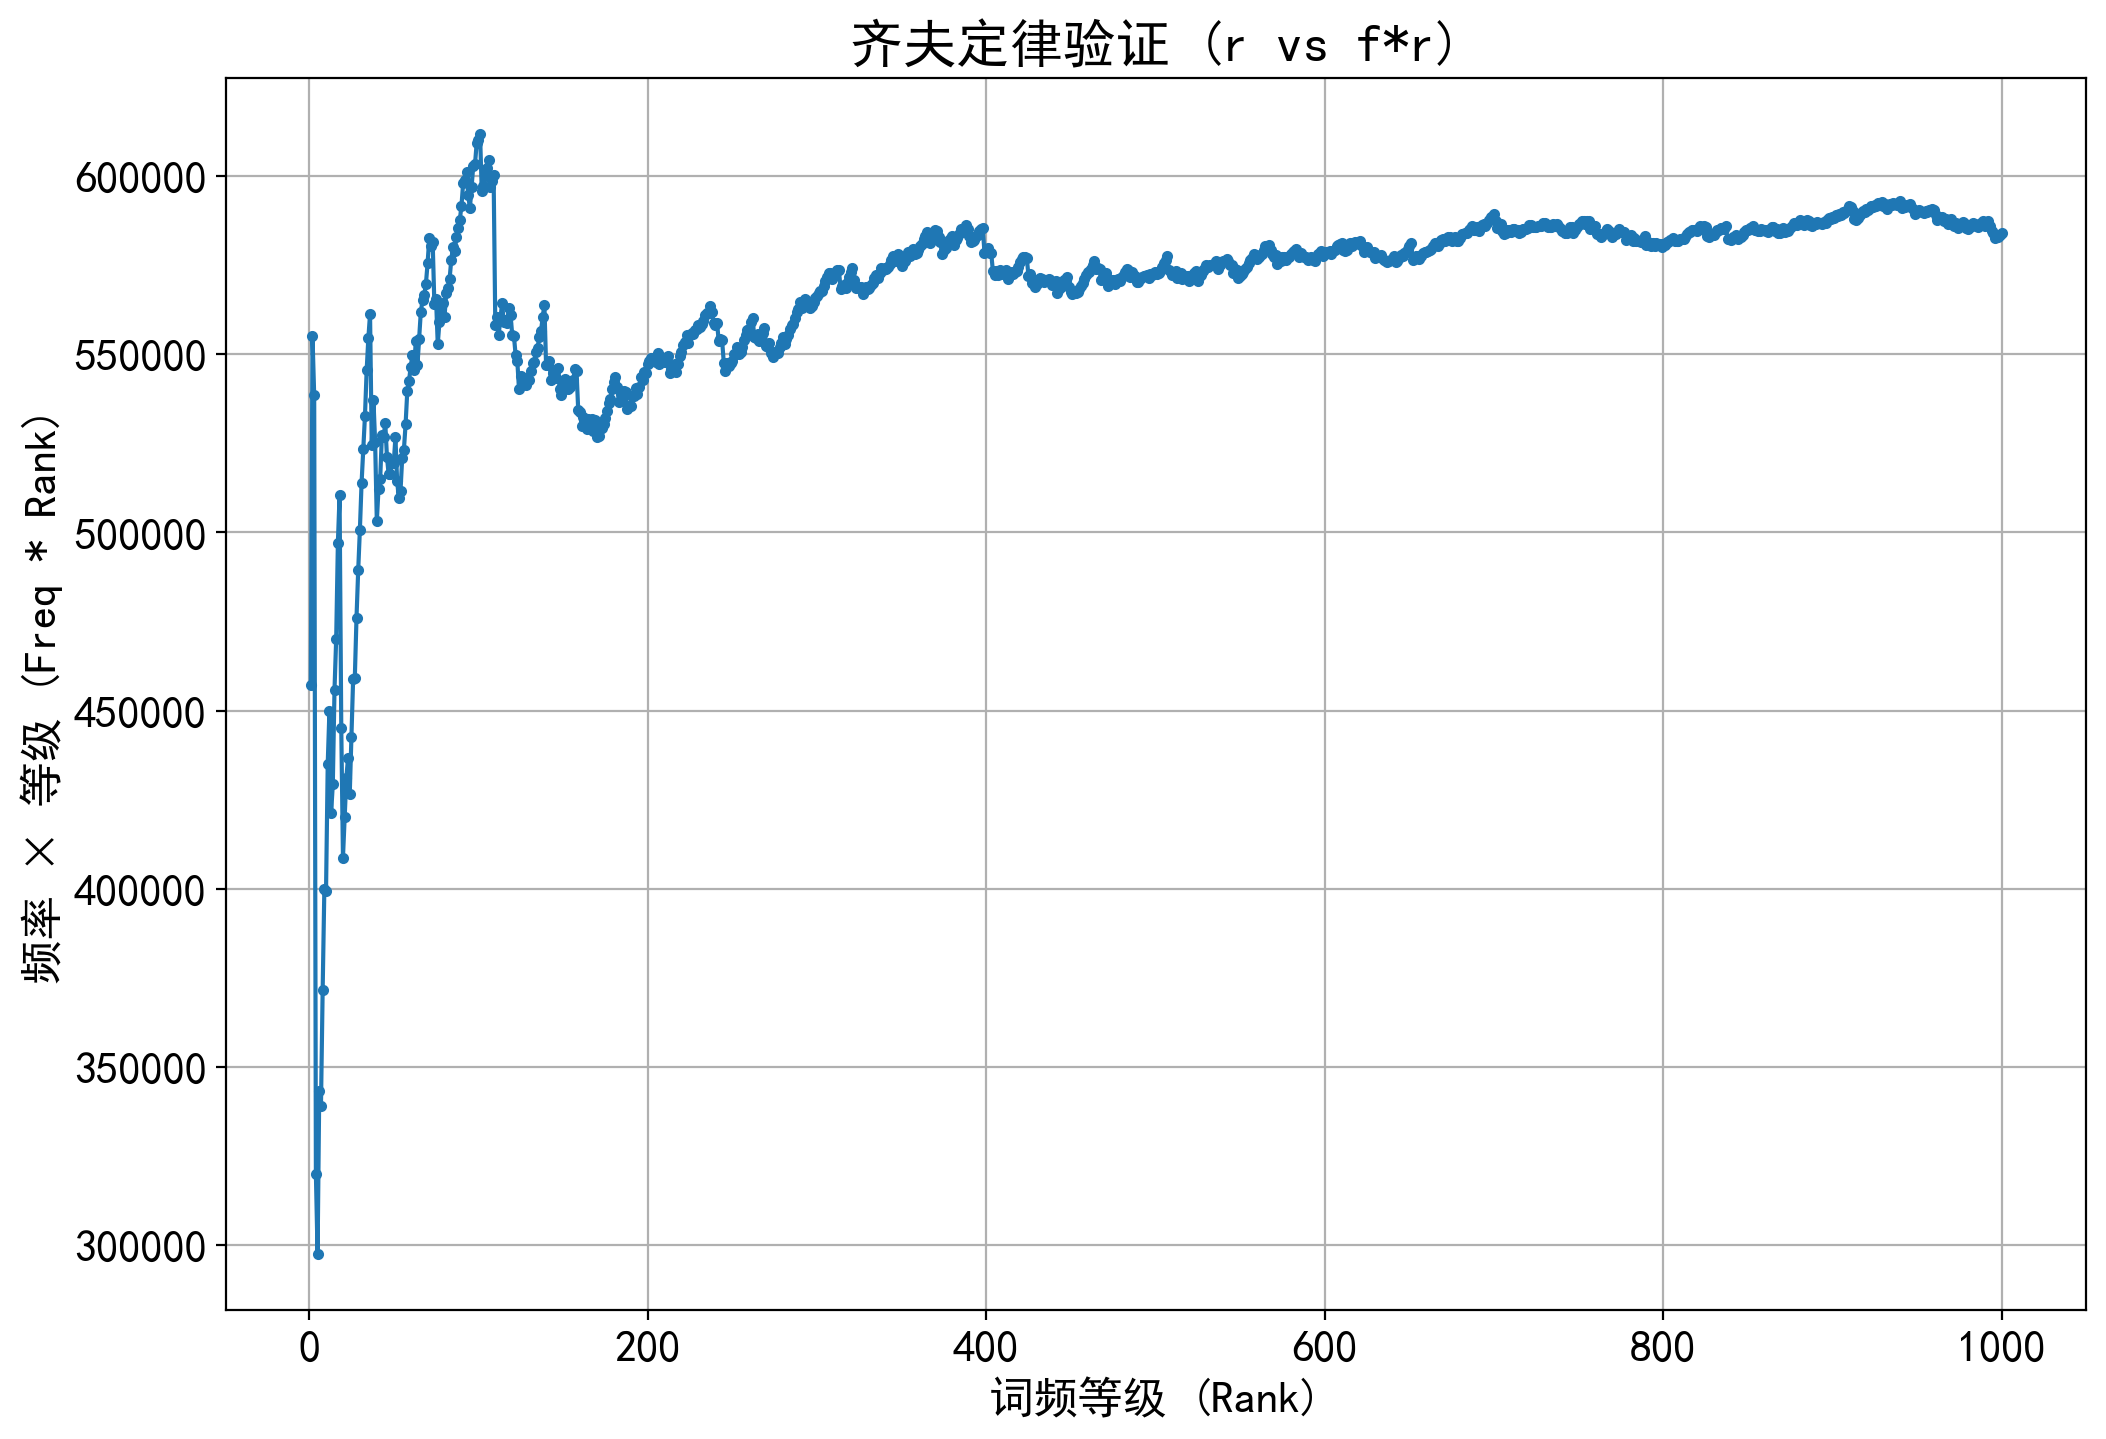

In [3]:
# 提取词语和频率
common_words, common_freqs = zip(*word_counts.most_common(1000))
ranks = np.arange(1, len(common_freqs) + 1)

# 绘制 r vs f*r 关系图
plt.figure(figsize=(12, 8))
plt.plot(ranks, ranks * np.array(common_freqs), "-o", markersize=3)
plt.title("齐夫定律验证 (r vs f*r)")
plt.xlabel('词频等级 (Rank)')
plt.ylabel('频率 × 等级 (Freq * Rank)')
plt.grid(True)
plt.show()

## 第二部分：实现基于词典的分词算法

### 1. 准备工作

In [6]:
from sys import getsizeof

def load_dictionary(dict_file):
    with open(dict_file, encoding="utf-8") as f:
        return {line.strip().split("\t")[0] for line in f}

word_dict = load_dictionary("./corpus_data/SogouW/Freq/SogouLabDic.dic")
print(f"词典大小: {len(word_dict)} 词")
print(f"词典占用内存: {getsizeof(word_dict) / 1024 / 1024:.2f} MB")

test_cases = [
    '项目的研究', '商品和服务', '研究生命起源',
    '当下雨天地面积水', '结婚的和尚未结婚的', '欢迎新老师生前来就餐'
]

词典大小: 157202 词
词典占用内存: 4.00 MB


### 2. 算法实现

前向最大匹配 (Forward Maximum Matching, FMM)

In [8]:
def forward_segment(text, dic):
    word_list = []
    i = 0
    while i < len(text):
        longest_word = text[i]                      # 当前扫描位置的单字
        for j in range(i + 1, len(text) + 1):       # 所有可能的结尾
            word = text[i:j]                        # 从当前位置到结尾的连续字符串
            if word in dic:                         # 在词典中
                if len(word) > len(longest_word):   # 并且更长
                    longest_word = word             # 则更优先输出
        word_list.append(longest_word)              # 输出最长词
        i += len(longest_word)                      # 正向扫描
    return word_list

print("--- 前向最大匹配 (FMM) 测试 ---")
for case in test_cases:
    print(forward_segment(case, word_dict))

--- 前向最大匹配 (FMM) 测试 ---
['项目', '的', '研究']
['商品', '和服务']
['研究生', '命', '起源']
['当下', '雨天', '地面', '积水']
['结婚', '的', '和尚', '未', '结婚', '的']
['欢迎新', '老师', '生前', '来', '就餐']


逆向最大匹配 (Backward Maximum Matching, BMM)

In [9]:
def backward_segment(text, dic):
    word_list = []
    i = len(text) - 1
    while i >= 0:                                   # 扫描位置作为终点
        longest_word = text[i]                      # 扫描位置的单字
        for j in range(0, i):                       # 遍历[0, i]区间作为待查询词语的起点
            word = text[j: i + 1]                   # 取出[j, i]区间作为待查询单词
            if word in dic:
                if len(word) > len(longest_word):   # 越长优先级越高
                    longest_word = word
                    break
        word_list.insert(0, longest_word)           # 逆向扫描，所以越先查出的单词在位置上越靠后
        i -= len(longest_word)
    return word_list

print("\n--- 逆向最大匹配 (BMM) 测试 ---")
for case in test_cases:
    print(backward_segment(case, word_dict))


--- 逆向最大匹配 (BMM) 测试 ---
['项', '目的', '研究']
['商品', '和服务']
['研究', '生命', '起源']
['当', '下雨天', '地面', '积水']
['结婚', '的', '和', '尚未', '结婚', '的']
['欢迎', '新老', '师生', '前来', '就餐']


双向最大匹配 (Bidirectional Maximum Matching)

In [10]:
def count_single_char(word_list: list):  # 统计单字成词的个数
    return sum(1 for word in word_list if len(word) == 1)


def bidirectional_segment(text, dic):
    f = forward_segment(text, dic)
    b = backward_segment(text, dic)
    if len(f) < len(b):                                  # 词数更少优先级更高
        return f
    elif len(f) > len(b):
        return b
    else:
        if count_single_char(f) < count_single_char(b):  # 单字更少优先级更高
            return f
        else:
            return b                                     # 都相等时逆向匹配优先级更高

print("\n--- 双向最大匹配测试 ---")
for case in test_cases:
    print(bidirectional_segment(case, word_dict))


--- 双向最大匹配测试 ---
['项', '目的', '研究']
['商品', '和服务']
['研究', '生命', '起源']
['当下', '雨天', '地面', '积水']
['结婚', '的', '和', '尚未', '结婚', '的']
['欢迎', '新老', '师生', '前来', '就餐']


### 3. 速度评测


--- 分词速度评测 ---
forward_segment       : 133.60 万字/秒
backward_segment      : 156.62 万字/秒
bidirectional_segment : 70.02 万字/秒


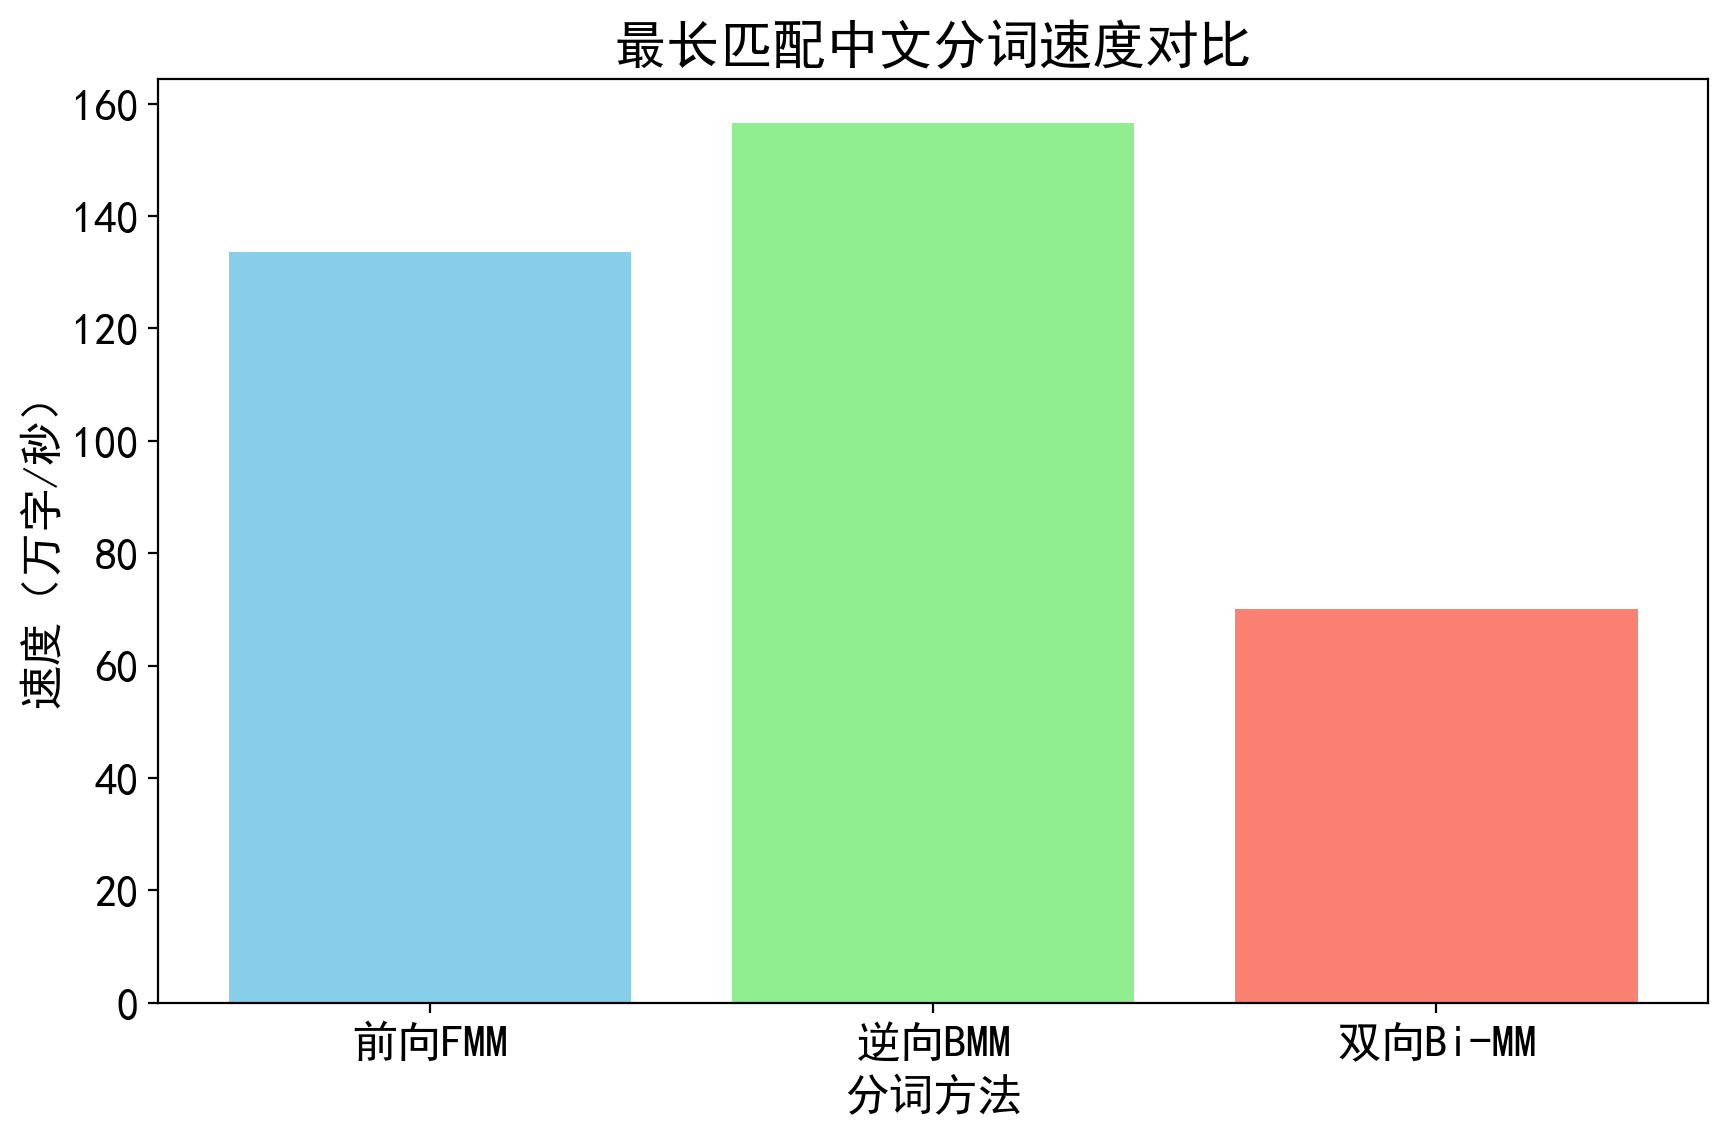

In [12]:
import time
def evaluate_speed(segment_func, text, dic, pressure):
    """
    评测分词函数的速度。
    :param segment_func: 待评测的分词函数。
    :param text: 测试文本。
    :param dic: 词典。
    :param pressure: 压力，即重复执行次数。
    """
    start_time = time.time()
    for _ in range(pressure):
        segment_func(text, dic)
    elapsed_time = time.time() - start_time
    # 计算每秒处理的字数（以万为单位）
    seg_speed = len(text) * pressure / 10000 / elapsed_time
    print(f'{segment_func.__name__:<22}: {seg_speed:.2f} 万字/秒')
    return seg_speed

text = "江西鄱阳湖干枯，中国最大淡水湖变成大草原"
pressure = 10000
segments_to_test = [forward_segment, backward_segment, bidirectional_segment]
results = []

print("\n--- 分词速度评测 ---")
for seg_func in segments_to_test:
    speed = evaluate_speed(seg_func, text, word_dict, pressure)
    results.append((seg_func.__name__, speed))

# 可视化速度对比结果
seg_names, speeds = zip(*results)
seg_labels = ("前向FMM", "逆向BMM", "双向Bi-MM")
plt.figure(figsize=(10, 6))
plt.bar(seg_labels, speeds, color=['skyblue', 'lightgreen', 'salmon'])
plt.title("最长匹配中文分词速度对比")
plt.xlabel('分词方法')
plt.ylabel('速度（万字/秒）')
plt.show()

这三种方法都是中文自然语言处理（NLP）中非常经典的**基于词典的分词算法**。

想象一下，你手里有一本“词典”，里面装满了所有合法的词汇。现在有一句连在一起的文本，你的任务是借助这本词典，把这句话“切”成一个个有意义的词。

“最大匹配”的核心原则就是：**贪心**。尽可能地去切出词典里能找到的**最长**的词，因为通常词越长，表达的意思越完整、越准确。

我们可以用一句经典的例子来体会它们的区别：**“研究生命的起源”**
假设我们的词典里有这些词：`["研究", "研究生", "生命", "命", "的", "起源"]`，设定的最大扫描长度是 3 个字。

### 1. 前向最大匹配 (Forward Maximum Matching)

**通俗理解**：从左往右看，能切多长切多长。

**工作过程**：从句子的开头向右扫描。

* **第一步**：先取前3个字“研究生”，去词典里查，发现有这个词！切下来。现在句子剩下“命的起源”。
* **第二步**：再看剩下的部分，取“命的起”去查，词典里没有；缩短一点查“命的”，也没有；再缩短查“命”，词典里有！切下来。剩下“的起源”。
* **第三步**：同样的方法，切出“的”。剩下“起源”。
* **第四步**：切出“起源”。

**最终结果**：研究生 / 命 / 的 / 起源

**缺点**：很明显，这里切错了。它是个“近视眼”，只管眼前的最长匹配，没考虑到后面的语境，导致把“研究”和“生命”错误地结合成了“研究生”。

### 2. 逆向最大匹配 (Backward Maximum Matching)

**通俗理解**：倒着来，从右往左看，能切多长切多长。

**工作过程**：从句子的末尾向左扫描。

* **第一步**：先取最后3个字“的起源”去查，词典里没有；缩短查“起源”，词典里有！切下来。剩下“研究生命的”。
* **第二步**：取末尾的“生命的”去查，没有；查“命的”，没有；查“的”，有！切下来。剩下“研究生命”。
* **第三步**：取末尾的“究生命”查，没有；查“生命”，有！切下来。剩下“研究”。
* **第四步**：查“研究”，有！切下来。

**最终结果**：研究 / 生命 / 的 / 起源

**优点**：这次切对了！由于汉语的语言习惯，很多词的重心或者修饰结构往往在后面，所以通常情况下，逆向最大匹配切错的概率会比前向最大匹配低一些。

### 3. 双向最大匹配 (Bidirectional Maximum Matching)

**通俗理解**：正着切一遍，反着切一遍，然后当个“裁判”，挑个更靠谱的结果。

**工作过程**：
既然前向和逆向各有优劣，那就把两个算法都跑一遍，然后对比它们的结果：

* **规则一：看词数。** 谁切出来的总词数越少，谁就越好（切成3个词总比切成5个词好，因为词越长越不容易把意思拆碎）。在我们的例子里，前向切了4个词，逆向也切了4个词，打平了。
* **规则二：看单字。** 如果总词数一样，就看谁切出来的“单字词”更少。单字词越少，说明切得越完整。在前向结果（研究生/命/的/起源）中有2个单字（命、的）；在逆向结果（研究/生命/的/起源）中有1个单字（的）。
* **规则三：看偏好。** 如果连单字词数量也一样，通常默认选择**逆向最大匹配**的结果，因为它的统计学准确率稍高。

**最终结果**：在这个例子中，逆向结果单字更少，双向最大匹配算法最终会选择**逆向最大匹配**的结果。

### 4. 数据结构优化

实现 Trie 类(前面用的set存储字典)

In [13]:
class Trie:

    def __init__(self):
        self.root = {}  # 用字典构建树结构
        self.end_of_word = '#'   # 用#标志一个单词的结束
    
    def insert(self, word: str):
        node = self.root
        for char in word:
            node = node.setdefault(char, {})
        node[self.end_of_word] = self.end_of_word
    
    # 查找一个单词是否完整的在字典树里，所以最后一句判断node是否等于#
    def search(self, word: str):
        node = self.root
        for char in word:
            if char not in node:
                return False
            node = node[char]
        return self.end_of_word in node
    
    def __contains__(self, word):
        """
        实现魔术方法，可以使用in或not in判断word是否在树中
        """
        return self.search(word)
        
    # 查找是否有一个单词是这个前缀开始的
    def startsWith(self, prefix: str):
        node = self.root
        for char in prefix:
            if char not in node:
                return False
            node = node[char]
        return True

性能对比

In [16]:
# 将词典加载到Trie中
trie_tree = Trie()
for word in word_dict:
    trie_tree.insert(word)

print(f"\n--- 数据结构性能对比 ---")
print(f"Trie 占用内存: {getsizeof(trie_tree.root) / 1024 / 1024:.2f} MB")
print(f"Set  占用内存: {getsizeof(word_dict) / 1024 / 1024:.2f} MB")

print("\n--- 使用 Trie 作为词典进行速度评测 ---")
for seg_func in segments_to_test:
    evaluate_speed(seg_func, text, trie_tree, pressure)


--- 数据结构性能对比 ---
Trie 占用内存: 0.14 MB
Set  占用内存: 4.00 MB

--- 使用 Trie 作为词典进行速度评测 ---
forward_segment       : 39.89 万字/秒
backward_segment      : 50.49 万字/秒
bidirectional_segment : 21.86 万字/秒


## 作业任务：实现改进的前向最大匹配算法并与前面的算法进行性能对比

--- 改进FMM测试 ---
['项目', '的', '研究']
['商品', '和服务']
['研究生', '命', '起源']
['当下', '雨天', '地面', '积水']
['结婚', '的', '和尚', '未', '结婚', '的']
['欢迎新', '老师', '生前', '来', '就餐']

--- 加入改进FMM后的速度评测 ---
forward_segment       : 143.85 万字/秒
backward_segment      : 150.76 万字/秒
bidirectional_segment : 66.54 万字/秒
<lambda>              : 251.24 万字/秒


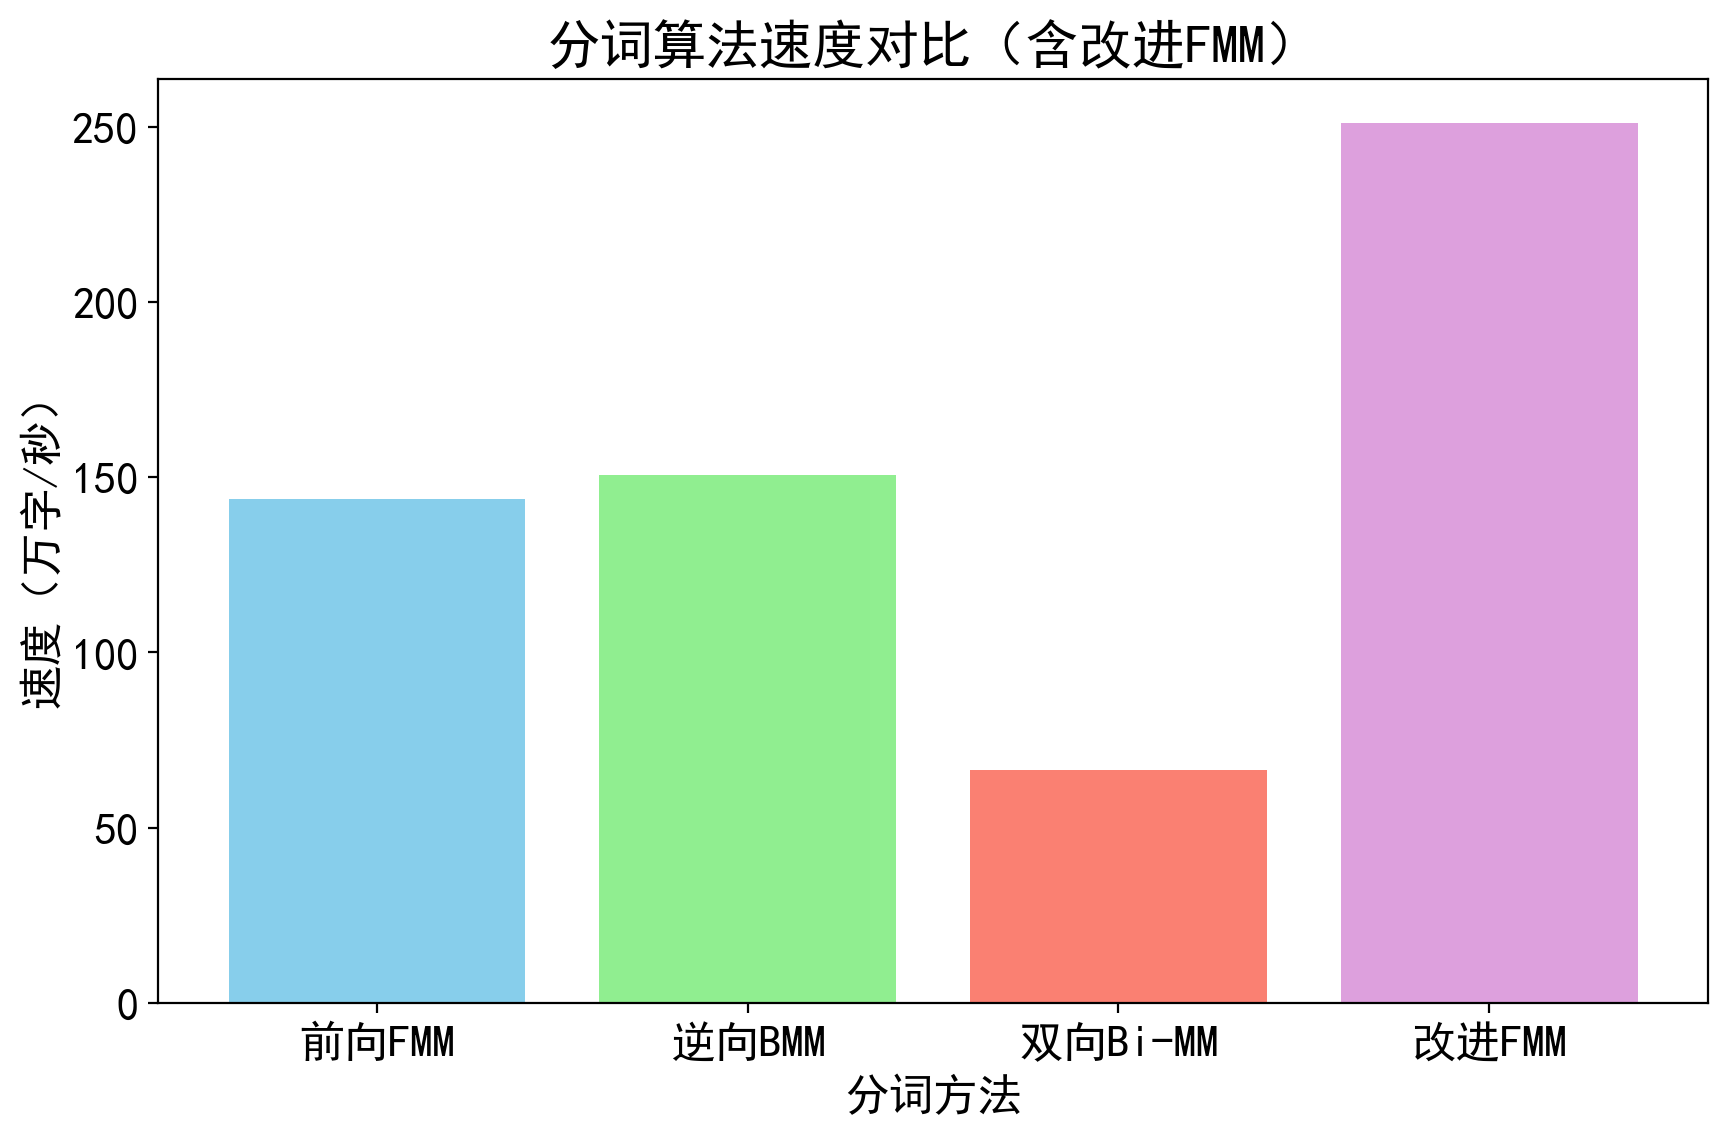

In [ ]:
# 改进的前向最大匹配（带“动态词典”学习单字）
def improved_forward_segment(text, dic, max_len=5):
    words = []
    dynamic_dic = set()  # 临时动态词典（仅当前句子有效）
    i = 0
    while True:
        n = len(text) - i
        if n == 0:
            break
        m = min(max_len, n)
        w = text[i:i + m]
        # 逐字缩短，直到命中词典或缩到1字
        while len(w) > 1 and (w not in dic) and (w not in dynamic_dic):
            w = w[:-1]
        # 若缩到单字仍不在词典，则强制切分并加入动态词典
        if (w not in dic) and (w not in dynamic_dic):
            dynamic_dic.add(w)
        words.append(w)
        i += len(w)
    return words

# 由词典自动确定最大词长（若过大可限制为5）
max_len_auto = min(5, max(map(len, word_dict)))

print("--- 改进FMM测试 ---")
for case in test_cases:
    print(improved_forward_segment(case, word_dict, max_len=max_len_auto))

# 与已有算法做速度对比
print("\n--- 加入改进FMM后的速度评测 ---")
segments_to_test_v2 = segments_to_test + [lambda t, d: improved_forward_segment(t, d, max_len=max_len_auto)]
segment_names_v2 = ["forward_segment", "backward_segment", "bidirectional_segment", "improved_forward_segment"]

results_v2 = []
for name, func in zip(segment_names_v2, segments_to_test_v2):
    speed_v = evaluate_speed(func, text, word_dict, pressure)
    results_v2.append((name, speed_v))

# 可视化
labels_v2 = ("前向FMM", "逆向BMM", "双向Bi-MM", "改进FMM")
_, speeds_v2 = zip(*results_v2)

plt.figure(figsize=(10, 6))
plt.bar(labels_v2, speeds_v2, color=["skyblue", "lightgreen", "salmon", "plum"])
plt.title("分词算法速度对比（含改进FMM）")
plt.xlabel("分词方法")
plt.ylabel("速度（万字/秒）")
plt.show()